## 11.03节练习参考答案

## 环境准备

In [ ]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import matplotlib.pyplot as plt
import torch
import math

from src.utils import train_2d, show_trace_2d, show_trace

本节的解答思路参考了 [《动手学深度学习》习题解答](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/ch11/ch11)。  

### 练习11.3.1
用不同的学习率和目标函数进行梯度下降实验

**解答：**

In [2]:
def f(x):  # 目标函数
    return x ** 2

def f_grad(x):  # 目标函数的梯度(导数)
    return 2 * x

def gd(eta, f_grad):
    x = 10.0
    results = [x]
    for i in range(10):
        x -= eta * f_grad(x)
        results.append(float(x))
    print(f'epoch 10, x: {x:f}')
    return results

def get_test(eta, f_grad, f=f):
  results = gd(eta, f_grad)
  show_trace(results, f)

epoch 10, x: 1.073742


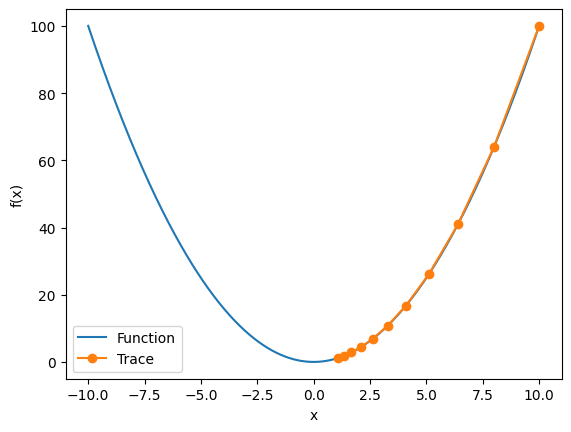

In [3]:
# x^2为目标函数
get_test(eta=0.1, f_grad=f_grad, f=f)

epoch 10, x: 8.170728


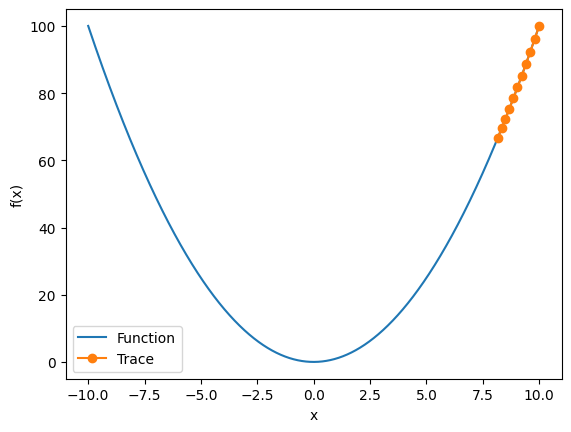

In [4]:
get_test(eta=0.01, f_grad=f_grad, f=f)

epoch 10, x: 3.486784


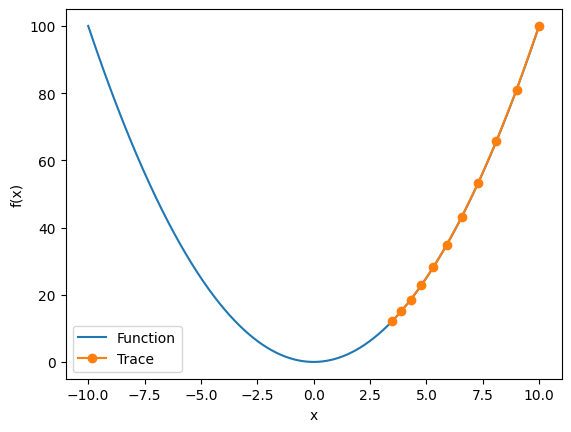

In [5]:
get_test(eta=0.05, f_grad=f_grad, f=f)

为了演示非凸函数的梯度下降，考虑函数f(x)=x⋅cos(cx)，其中c为某常数。 这个函数有无穷多个局部最小值。 根据我们选择的学习率，我们最终可能只会得到许多解的一个。 下面的例子说明了（不切实际的）高学习率如何导致较差的局部最小值

In [6]:
c = torch.tensor(0.15 * np.pi)

def f2(x):  # 目标函数
    return x * torch.cos(c * x)

def f_grad2(x):  # 目标函数的梯度
    return torch.cos(c * x) - c * x * torch.sin(c * x)

epoch 10, x: 8.284779


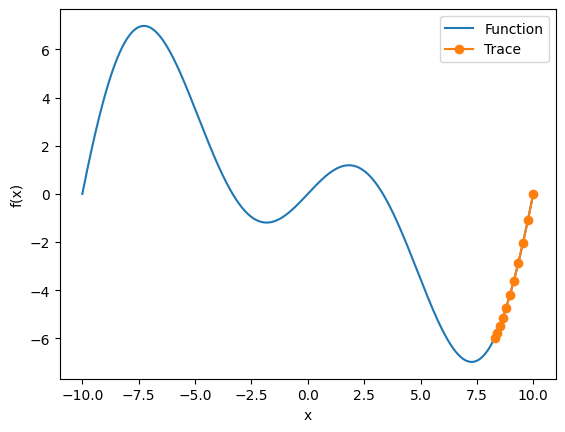

In [7]:
get_test(eta=0.05, f_grad=f_grad2, f=f2)

In [8]:
c = torch.tensor(0.5)

def f(x):  # O目标函数
    return torch.cosh(c * x)

def f_grad(x):  # 目标函数的梯度
    return c * torch.sinh(c * x)

def f_hess(x):  # 目标函数的Hessian
    return c**2 * torch.cosh(c * x)

def newton(eta=1):
    x = 10.0
    results = [x]
    for i in range(10):
        x -= eta * f_grad(x) / f_hess(x)
        results.append(float(x))
    print('epoch 10, x:', x)
    return results

epoch 10, x: tensor(0.)


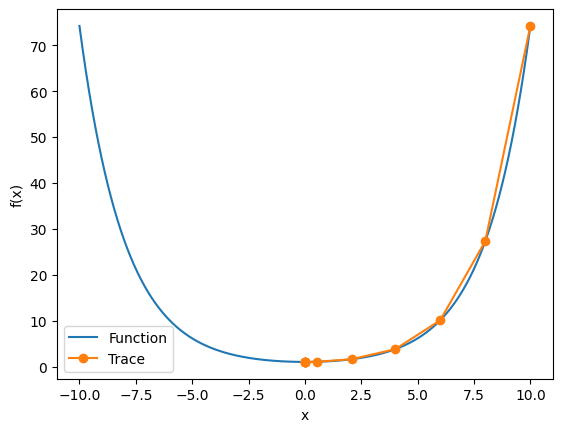

In [9]:
show_trace(newton(), f)

现在让我们考虑一个非凸函数，比如f(x)=xcos(cx)，c为某些常数。 请注意在牛顿法中，我们最终将除以Hessian。 这意味着如果二阶导数是负的，f的值可能会趋于增加。 这是这个算法的致命缺陷！

In [10]:
c = torch.tensor(0.15 * np.pi)

def f(x):  # 目标函数
    return x * torch.cos(c * x)

def f_grad(x):  # 目标函数的梯度
    return torch.cos(c * x) - c * x * torch.sin(c * x)

def f_hess(x):  # 目标函数的Hessian
    return - 2 * c * torch.sin(c * x) - x * c**2 * torch.cos(c * x)

epoch 10, x: tensor(26.8341)


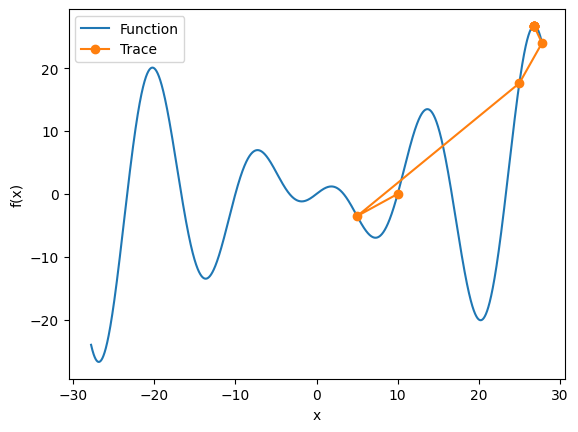

In [11]:
show_trace(newton(), f)

### 练习11.3.2
在区间$[a, b]$中实现线搜索以最小化凸函数。
1. 是否需要导数来进行二分搜索，即决定选择$[a, (a+b)/2]$还是$[(a+b)/2, b]$。
1. 算法的收敛速度有多快？
1. 实现该算法，并将其应用于求$\log (\exp(x) + \exp(-2x -3))$的最小值。

**解答：**

(1) 需要。凸函数的极小点满足 $f'(x^*)=0$。二分法在中点 $m=(a+b)/2$ 处看 $f'(m)$ 的符号：$f'(m)>0$ 则极小点在 $[a,m]$，反之为 $[m,b]$。因此二分搜索依赖导数；仅用函数值则需改用黄金分割法（取两个内点比较函数值）。

(2) 每次区间减半，线性收敛，$|b_n-a_n|=2^{-n}(b_0-a_0)$。

(3) 实现如下（基于导数符号的二分搜索）：

argmin = -0.768950879573822


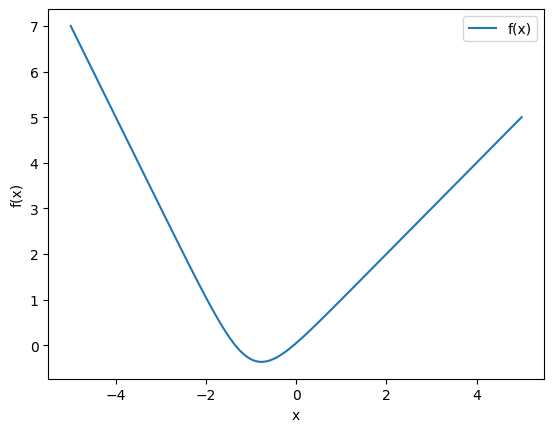

In [12]:
def convex_function(x):
    return np.log(np.exp(x) + np.exp(-2*x-3))

def convex_grad(x):
    e1, e2 = np.exp(x), np.exp(-2*x-3)
    return (e1 - 2*e2) / (e1 + e2)

def bisection_line_search(a, b, grad, eps=1e-6):
    results = []
    while abs(b - a) > eps:
        m = (a + b) / 2
        if grad(m) > 0:
            b = m
        else:
            a = m
        results.append((a, b))
    return a, b, results

a, b = -5, 5
a, b, results = bisection_line_search(a, b, convex_grad)
print('argmin =', (a + b) / 2)

x = np.linspace(-5, 5, 100)
plt.plot(x, convex_function(x), label='f(x)')
plt.xlabel('x'); plt.ylabel('f(x)'); plt.legend(); plt.show()

### 练习11.3.3
设计一个定义在$\mathbb{R}^2$上的目标函数，它的梯度下降非常缓慢。提示：不同坐标的缩放方式不同。

**解答：**

epoch 20, x1: -0.057646, x2: -0.000073


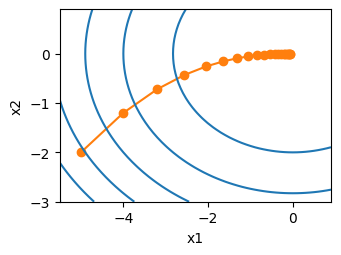

In [13]:
def f_2d(x1, x2):
    return x1 ** 2 + 2 * x2 ** 2

def f_2d_grad(x1, x2):
    return (2 * x1, 4 * x2)

def gd_2d(x1, x2, s1, s2, f_grad):
    g1, g2 = f_grad(x1, x2)
    return (x1 - eta * g1, x2 - eta * g2, 0, 0)

eta = 0.1
results = train_2d(gd_2d, f_grad=f_2d_grad)
show_trace_2d(f_2d, results)

epoch 100, x1: -0.663098, x2: -0.000000


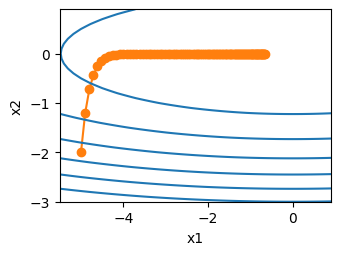

In [14]:
# a 和 b为放缩因子
def slow_f_2d(x1, x2, a=0.1, b=1):
    return  a*x1 ** 2 +  b*2 * x2 ** 2

def slow_f_2d_grad(x1, x2, a=0.1, b=1):
    return (a * 2 * x1, b * 4 * x2)

eta = 0.1
results = train_2d(gd_2d, steps=100,f_grad=slow_f_2d_grad)
show_trace_2d(slow_f_2d, results)

### 练习11.3.4
使用预处理实现牛顿方法的轻量版本。
1. 使用对角Hessian作为预条件子。
1. 使用它的绝对值，而不是实际值（可能有符号）。
1. 将此应用于上述问题。

**解答：**

预处理：计算和存储完整的$\mathrm{Hessian}$非常昂贵，而改善这个问题的一种方法是“预处理”。它回避了计算整个$\mathrm{Hessian}$，而只计算对角线项，取如下的算法更新：

$$
\mathbf{x} \leftarrow \mathbf{x} - \eta\,\mathrm{diag}(\mathbf{H})^{-1}\nabla f(\mathbf{x}).
$$

In [15]:
def newton_preconditioned(eta=1):
    x = 10.0
    results = [x]
    for i in range(10):
        preconditioner = torch.abs(f_hess(x))  # 预条件子为Hessian的绝对值
        x -= eta * f_grad(x) / preconditioner
        results.append(float(x))
    print('epoch 10, x:', x)
    return results

epoch 10, x: tensor(0.)


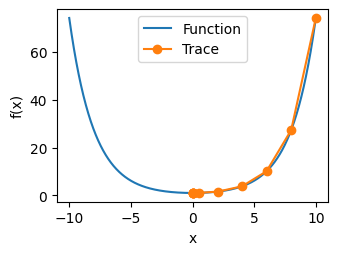

In [16]:
c = torch.tensor(0.5)

def f(x):  # 目标函数
    return torch.cosh(c * x)

def f_grad(x):  # 目标函数的梯度
    return c * torch.sinh(c * x)

def f_hess(x):  # 目标函数的Hessian
    return c**2 * torch.cosh(c * x)

results = newton_preconditioned()
show_trace(results, f)

epoch 10, x: tensor(20.2219)


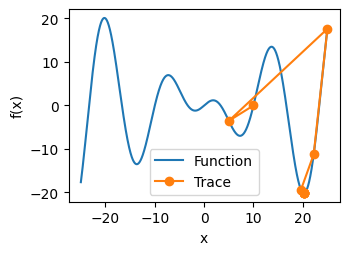

In [17]:
c = torch.tensor(0.15 * np.pi)

def f(x):  # 目标函数
    return x * torch.cos(c * x)

def f_grad(x):  # 目标函数的梯度
    return torch.cos(c * x) - c * x * torch.sin(c * x)

def f_hess(x):  # 目标函数的Hessian
    return - 2 * c * torch.sin(c * x) - x * c**2 * torch.cos(c * x)

results = newton_preconditioned()
show_trace(results, f)

epoch 20, x1: -0.000000, x2: -0.000073


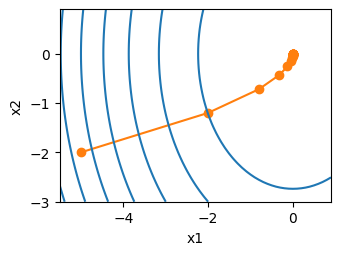

In [18]:
def f_2d(x1, x2):
    return 3 * x1 ** 2 + 2 * x2 ** 2

def f_2d_grad(x1, x2):
    return (6 * x1, 4 * x2)

def gd_2d(x1, x2, s1, s2, f_grad):
    g1, g2 = f_grad(x1, x2)
    return (x1 - eta * g1, x2 - eta * g2, 0, 0)

eta = 0.1
results = train_2d(gd_2d, f_grad=f_2d_grad)
show_trace_2d(f_2d, results)

epoch 20, x1: 0.000000, x2: 0.000000


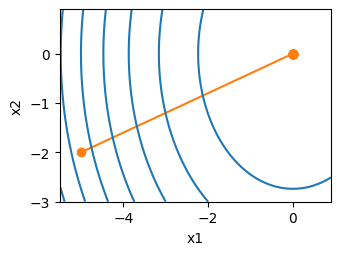

In [19]:
def rotation(x1, x2):
    xa = (x1 + x2) / math.sqrt(2)
    xb = (x2 - x1) / math.sqrt(2)
    return xa, xb

def newton_2d(x1, x2, s1, s2, f_grad, f_hessian):
    g1, g2 = f_grad(x1, x2)
    h11, h12, h21, h22 = f_hessian(x1, x2)

    # 计算预处理的牛顿法步长
    det_hessian = h11 * h22 - h12 * h21
    inv_hessian = (h22 / det_hessian, -h12 / det_hessian, -h21 / det_hessian, h11 / det_hessian)

    # 计算更新后的位置
    delta_x1 = inv_hessian[0] * g1 + inv_hessian[1] * g2
    delta_x2 = inv_hessian[2] * g1 + inv_hessian[3] * g2

    return (x1 - delta_x1, x2 - delta_x2, 0, 0)

def f_hessian(x1, x2):
    h11 = 6
    h12 = 0
    h21 = 0
    h22 = 4
    return h11, h12, h21, h22

def train_2d_hessian(trainer, steps=20, f_grad=None, f_hessian=f_hessian, is_rotation=True):
    x1, x2, s1, s2 = -5, -2, 0, 0
    if is_rotation:
      x1, x2 = rotation(x1, x2)
    results = [(x1, x2)]
    for i in range(steps):
        if f_grad:
            x1, x2, s1, s2 = trainer(x1, x2, s1, s2, f_grad, f_hessian)
        else:
            x1, x2, s1, s2 = trainer(x1, x2, s1, s2, f_hessian)
        results.append((x1, x2))
    print(f'epoch {i + 1}, x1: {float(x1):f}, x2: {float(x2):f}')
    return results


results = train_2d_hessian(newton_2d, f_grad=f_2d_grad,is_rotation=False)
show_trace_2d(f_2d, results)

epoch 20, x1: 0.000000, x2: 0.000000


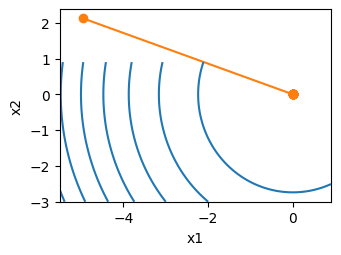

In [20]:
eta = 0.1
results = train_2d_hessian(newton_2d, f_grad=f_2d_grad,is_rotation=True)
show_trace_2d(f_2d, results)